In [2]:
import numpy as np
import pandas
import dpluspy
import moments
import demes

In [3]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [4]:
dfs = []

for rep in range(10):
    df = pandas.read_csv(f"results/ghost_den_fit_null_{rep}.csv")
    best_fit = df[df["ll"] == np.max(df["ll"])]
    best_fit = best_fit.assign(model=f"rep{rep}")
    dfs.append(best_fit)

for model in range(693):
    try:
        df = pandas.read_csv(f"results/ghost_den_fit_{model}.csv")
        best_fit = df[df["ll"] == np.max(df["ll"])]
        best_fit = best_fit.assign(model=model)
        dfs.append(best_fit)
    except:
        print(f"missing fit {model}")
df = pandas.concat(dfs)
df.to_csv("best_fits.csv", index=False)

missing fit 44
missing fit 69
missing fit 85
missing fit 130
missing fit 163
missing fit 338
missing fit 402
missing fit 600
missing fit 622


In [5]:
df[np.isnan(df["T_Gho"])]

,ll,T_NDH,T_ND,T_AMH_Alt,p_AMH_Alt,N_Anc,N_Yor,N_ND,N_Den,N_Alt,model,T_Gho,T_Gho_Den,p_Gho_Den,N_Gho
3,-43.333221,762903.487142,717896.602210,300818.707818,0.111161,16497.576963,27013.357479,1555.656197,4074.474789,2588.943183,rep0,NaN,NaN,NaN,NaN
2,-43.316723,766683.190489,708969.068014,302093.490806,0.111447,16440.346429,27121.647001,2005.984403,4044.430157,2589.820790,rep1,NaN,NaN,NaN,NaN
5,-43.343046,761726.612700,718558.362579,301133.149419,0.111269,16515.484843,26979.647892,1491.552732,4076.819396,2590.882046,rep2,NaN,NaN,NaN,NaN
0,-43.342740,761941.537643,718785.533181,301693.127181,0.111552,16512.391990,26985.345701,1490.036905,4077.553548,2592.793416,rep3,NaN,NaN,NaN,NaN
3,-43.926580,750316.076435,735163.818576,301439.524051,0.111818,16690.196522,26649.896720,516.692462,4131.497141,2599.280628,rep4,NaN,NaN,NaN,NaN
0,-43.395194,771446.523552,697336.850054,302904.487960,0.111641,16367.593049,27255.768743,2594.111955,4004.130403,2585.459385,rep5,NaN,NaN,NaN,NaN
1,-43.322052,763715.277299,715539.747069,301531.428108,0.111449,16485.806170,27036.160422,1667.281006,4066.823009,2590.313349,rep6,NaN,NaN,NaN,NaN
1,-43.410714,772031.764462,696170.271987,303818.577396,0.111600,16358.360620,27275.244715,2657.438290,4000.048715,2591.700760,rep7,NaN,NaN,NaN,NaN
0,-43.491859,757112.751032,728051.492199,301058.017062,0.111556,16586.235013,26845.514837,996.854995,4108.022449,2593.967081,rep8,NaN,NaN,NaN,NaN
4,-43.321126,763665.347527,714333.947058,302649.307246,0.111647,16485.693329,27034.967343,1708.382712,4062.687856,2596.123015,rep9,NaN,NaN,NaN,NaN


In [6]:
df[df["ll"] == np.max(df["ll"])]

,ll,T_NDH,T_ND,T_AMH_Alt,p_AMH_Alt,N_Anc,N_Yor,N_ND,N_Den,N_Alt,model,T_Gho,T_Gho_Den,p_Gho_Den,N_Gho
5,-32.663691,772913.866063,745682.685436,249067.229844,0.086185,16273.960311,27505.83466,940.52038,3688.57633,2414.761295,48,4.000000e+06,96478.780621,0.001004,6487.692713


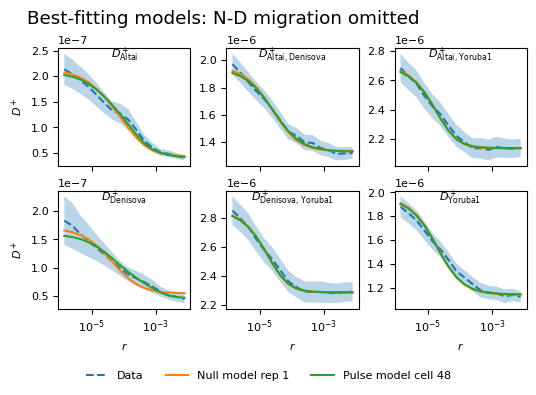

In [11]:
u = 1.3e-8
graph0 = "results/ghost_den_fit_null_1.yaml"
graph1 = "results/ghost_den_fit_48.yaml"
data_file = "../../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
data = dpluspy.inference.load_stats(
    data_file, graph=graph0, return_dict=True)
model0 = dpluspy.inference.compute_bin_stats(graph0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model1 = dpluspy.inference.compute_bin_stats(graph1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    labels=["Data", "Null model rep 1", "Pulse model cell 48"],
    title="Best-fitting models: N-D migration omitted",
    out="figures/best_fit_model.png",
    cols=3,
    ax_size=1.75
)